In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, re
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support

In [2]:
root = Path("../..")

In [3]:
DATASET_DIR = root / "data" / 'processed'
DATASET_PATH = DATASET_DIR / "processed_df_1.csv"
DATASET_DIR.exists(), DATASET_PATH.exists() # must be True

(True, True)

In [4]:
df = pd.read_csv(DATASET_PATH)
df.head()

,role,message_number,sentence_number,sentence,tag,dialogue_number,sentence_clean
0,Proponent,0,1,What is the type of knowledge that is injected...,ask_info,0,what is the type of knowledge that is injected...
1,Domain Expert,1,1,We inject domain knowledge from Constrained Sa...,reply_info,0,we inject domain knowledge from constrained sa...
2,Proponent,2,0,Interesting!,give_opinion,0,interesting!
3,Proponent,2,1,What is the problem used to perform the experi...,ask_info,0,what is the problem used to perform the experi...
4,Domain Expert,3,0,We employ the Partial Latin Square completion ...,reply_info,0,we employ the partial latin square completion ...


In [5]:
required_columns = ["dialogue_number", "sentence_clean", "tag"]
optional_order_columns = ["message_number", "sentence_number"]
optional_feature_columns = ["role"]

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

In [6]:
df_temp = df.copy(deep=True)

In [7]:
print(df_temp.shape)
print(df_temp["tag"].value_counts())

(750, 7)
tag
reply_info        322
ask_info          221
give_opinion      123
ask_rebuttal       49
ask_suggestion     35
Name: count, dtype: int64


- Note: Naive Bayes is a flat, per-sentence classifier with no sequence awareness. It predicts each sentence's intent tag independently, with no knowledge of previous or future tags. This makes it the ideal baseline: any improvement from HMM, MEMM, or CRF over Naive Bayes directly quantifies the benefit of modelling intent transitions across dialogue turns.

- Note: We use `ComplementNB` rather than `MultinomialNB` because it handles class imbalance better by learning from the complement of each class, which tends to perform more robustly on skewed label distributions.

#### Feature extraction

- Note: We use the same handcrafted feature set as MEMM and CRF (wh-words, modal/request markers, negation, pronoun cues, punctuation cues, unigram+bigram BoW) for a fair comparison. The only difference is that `prev_tag` is never passed — Naive Bayes has no sequence memory.

In [8]:
def extract_features(
    text: str,
    turn_idx: int = 0,
    total_turns: int = 1,
    speaker_role=None,
    prev_text=None,
) -> dict:
    """
    Feature extraction for Naive Bayes dialogue act tagging.
    Identical to MEMM/CRF features, minus prev_tag (no sequence memory).

    Args:
        text:         Current utterance text.
        turn_idx:     Index of this turn in the conversation (0-based).
        total_turns:  Total number of turns in the conversation.
        speaker_role: Speaker role string e.g. 'DOMAIN_EXPERT' or 'PROPONENT'.
        prev_text:    Text of the previous utterance (or None).
    """

    raw_text = str(text)
    clean    = raw_text.lower().strip()
    tokens   = re.findall(r"[a-zA-Z']+", clean)
    n_tokens = len(tokens)

    features = {}

    # Bias & surface statistics
    features["bias"]          = 1
    features["num_tokens"]    = n_tokens
    features["char_len"]      = len(clean)
    features["avg_token_len"] = (sum(len(t) for t in tokens) / n_tokens) if n_tokens else 0

    # Punctuation cues
    features["has_question_mark"]   = int("?" in raw_text)
    features["has_exclamation"]     = int("!" in raw_text)
    features["question_mark_count"] = raw_text.count("?")
    features["exclamation_count"]   = raw_text.count("!")
    features["has_ellipsis"]        = int("..." in raw_text)

    # First / last token cues
    first_token = tokens[0]  if tokens else "<EMPTY>"
    last_token  = tokens[-1] if tokens else "<EMPTY>"
    features[f"first_token={first_token}"] = 1
    features[f"last_token={last_token}"]   = 1

    wh_words = {"what", "why", "how", "when", "where", "who", "which"}
    aux_starters = {
        "do", "does", "did", "is", "are", "was", "were",
        "can", "could", "would", "should", "will", "shall", "might", "may"
    }
    features["starts_with_wh"]  = int(first_token in wh_words)
    features["starts_with_aux"] = int(first_token in aux_starters)
    features["ends_with_right"] = int(last_token in {"right", "correct", "yes", "no"})

    # Pronoun cues
    first_person  = {"i", "me", "my", "mine", "we", "our", "ours", "us"}
    second_person = {"you", "your", "yours"}
    third_person  = {"he", "she", "they", "it", "his", "her", "their", "its"}

    features["has_first_person"]  = int(any(t in first_person  for t in tokens))
    features["has_second_person"] = int(any(t in second_person for t in tokens))
    features["has_third_person"]  = int(any(t in third_person  for t in tokens))

    fp_count = sum(1 for t in tokens if t in first_person)
    features["first_person_ratio"] = fp_count / n_tokens if n_tokens else 0

    # Negation
    negation_tokens = {"not", "no", "never", "neither", "nor", "nobody", "nothing", "nowhere"}
    features["has_negation"]   = int(any(t in negation_tokens for t in tokens) or "n't" in clean)
    features["negation_count"] = sum(1 for t in tokens if t in negation_tokens)

    # WH-word density
    wh_count = sum(1 for t in tokens if t in wh_words)
    features["wh_word_count"] = wh_count
    features["wh_word_ratio"] = wh_count / n_tokens if n_tokens else 0

    # Marker groups
    info_request_markers = [
        "can you", "could you", "do you know", "tell me",
        "explain", "clarify", "please describe", "what is",
        "what are", "how does", "why does", "who is"
    ]
    suggestion_markers = [
        "should", "maybe", "try", "recommend", "suggest",
        "consider", "you can", "we can", "it may be better",
        "it would be better", "one option", "another option",
        "have you tried", "you might want"
    ]
    opinion_markers = [
        "i think", "i believe", "i feel", "in my opinion",
        "to me", "seems", "seem", "interesting", "promising",
        "strong", "weak", "better", "worse", "useful",
        "important", "significant", "impressive", "concerning"
    ]
    strong_rebuttal_markers = [
        "i disagree", "that's not", "are you sure", "not necessarily",
        "on the contrary", "actually,", "in fact,", "i don't think",
        "that doesn't", "isn't that", "wouldn't that", "i'm not sure",
        "do you really", "that may not"
    ]
    weak_rebuttal_markers = [
        "but", "however", "although", "still", "yet",
        "on the other hand", "even so", "that said"
    ]
    answer_markers = [
        "yes", "no", "because", "therefore", "it is",
        "this is", "that is", "the answer", "indeed",
        "exactly", "correct", "precisely", "absolutely"
    ]
    topic_markers = [
        "next", "another", "move on", "switch", "turn to",
        "let us discuss", "let's discuss", "moving on",
        "the next point", "shifting to"
    ]
    positive_stance = ["good", "great", "agree", "correct", "right", "exactly", "well done"]
    negative_stance = ["bad", "wrong", "disagree", "incorrect", "unfortunately", "sadly"]
    hedging_markers = [
        "maybe", "perhaps", "might", "possibly",
        "i think", "i believe", "seems like", "it appears"
    ]

    marker_groups = {
        "info_request":    info_request_markers,
        "suggestion":      suggestion_markers,
        "opinion":         opinion_markers,
        "strong_rebuttal": strong_rebuttal_markers,
        "weak_rebuttal":   weak_rebuttal_markers,
        "answer":          answer_markers,
        "topic":           topic_markers,
        "positive_stance": positive_stance,
        "negative_stance": negative_stance,
        "hedging":         hedging_markers,
    }

    for group_name, markers in marker_groups.items():
        hits = sum(1 for m in markers if m in clean)
        features[f"has_{group_name}"]   = int(hits > 0)
        features[f"count_{group_name}"] = hits

    features["has_any_rebuttal"] = int(
        features["has_strong_rebuttal"] or features["has_weak_rebuttal"]
    )

    # Speaker role
    if speaker_role is not None:
        role_clean = str(speaker_role).upper().strip()
        features[f"speaker_role={role_clean}"] = 1
        features["is_domain_expert"] = int("DOMAIN_EXPERT" in role_clean)
        features["is_proponent"]     = int("PROPONENT"     in role_clean)
    else:
        features["is_domain_expert"] = 0
        features["is_proponent"]     = 0

    # Conversation position
    features["turn_index"]        = turn_idx
    features["is_first_turn"]     = int(turn_idx == 0)
    features["is_last_turn"]      = int(turn_idx == total_turns - 1)
    features["relative_position"] = turn_idx / total_turns if total_turns else 0

    # Previous-utterance text features
    if prev_text is not None:
        prev_raw    = str(prev_text)
        prev_clean  = prev_raw.lower().strip()
        prev_tokens = re.findall(r"[a-zA-Z']+", prev_clean)

        features["prev_has_question_mark"] = int("?" in prev_raw)
        features["prev_num_tokens"]        = len(prev_tokens)
        features["prev_starts_with_wh"]    = int(
            bool(prev_tokens) and prev_tokens[0] in wh_words
        )
        features[f"prev_first_token={prev_tokens[0] if prev_tokens else '<EMPTY>'}"] = 1
        features["prev_looks_like_question"] = int(
            features["prev_has_question_mark"] or features["prev_starts_with_wh"]
        )
    else:
        features["prev_has_question_mark"]   = 0
        features["prev_num_tokens"]          = 0
        features["prev_starts_with_wh"]      = 0
        features["prev_looks_like_question"] = 0

    # Note: prev_tag is intentionally omitted.
    # Naive Bayes makes each prediction independently, with no sequence memory.

    # Lightweight BoW: unigrams and bigrams
    for token in tokens:
        features[f"word={token}"] = 1

    for w1, w2 in zip(tokens, tokens[1:]):
        features[f"bigram={w1}_{w2}"] = 1

    return features

In [9]:
def row_to_features(row, prev_text=None):
    speaker_role = None
    if "role" in row.index and pd.notna(row["role"]):
        speaker_role = str(row["role"])

    turn_idx    = int(row["_sent_position"]) if "_sent_position" in row.index else 0
    total_turns = int(row["_total_turns"])   if "_total_turns"   in row.index else 1

    return extract_features(
        text         = row["sentence_clean"],
        turn_idx     = turn_idx,
        total_turns  = total_turns,
        speaker_role = speaker_role,
        prev_text    = prev_text,
    )

- Note: Naive Bayes classifies each sentence in isolation. Unlike MEMM (which passes `prev_tag` explicitly) and CRF (which learns tag transitions jointly), Naive Bayes receives no information about what label came before. This is the defining limitation we are measuring against.

In [10]:
sort_cols = [col for col in ["dialogue_number", "message_number", "sentence_number"] if col in df_temp.columns]

def sort_dialogue(group):
    return group.sort_values(sort_cols).reset_index(drop=True)

def add_sequence_context(group):
    group = sort_dialogue(group).copy()
    group["_sent_position"] = np.arange(len(group))
    group["_total_turns"] = len(group)

    if "role" in group.columns:
        group["_prev_role"] = group["role"].shift(1).fillna("START")
        group["_speaker_changed"] = (group["role"] != group["role"].shift(1)).astype(int)
        group.loc[0, "_speaker_changed"] = 0
    else:
        group["_prev_role"] = "START"
        group["_speaker_changed"] = 0

    return group

def make_nb_training_data(data):
    X_features = []
    y_labels = []

    for _, group in data.groupby("dialogue_number"):
        group = add_sequence_context(group)

        prev_text = None

        for _, row in group.iterrows():
            features = row_to_features(row, prev_text=prev_text)

            X_features.append(features)
            y_labels.append(row["tag"])

            prev_text = row["sentence_clean"]

    return X_features, y_labels

- Example: features = sentence features (no prev_tag), label = ask_info

### Dialogue-level train-test split

In [11]:
dialogue_ids = sorted(df_temp["dialogue_number"].unique())

In [12]:
train_ids, test_ids = train_test_split(
    dialogue_ids,
    test_size=0.2,
    random_state=42
)

In [13]:
train_df = df_temp[df_temp["dialogue_number"].isin(train_ids)].copy()
test_df  = df_temp[df_temp["dialogue_number"].isin(test_ids)].copy()

In [14]:
print("Train dialogues:", train_df["dialogue_number"].nunique())
print("Test dialogues:",  test_df["dialogue_number"].nunique())

print("Train rows:", len(train_df))
print("Test rows:",  len(test_df))

assert set(train_df["dialogue_number"]).isdisjoint(set(test_df["dialogue_number"]))

Train dialogues: 32
Test dialogues: 9
Train rows: 574
Test rows: 176


- Note: We cannot have sentences from the same dialogue belong to training and test datasets, that could cause data leakage at the dialogue level.

### Creating feature instances for each sentence

In [15]:
X_train_features, y_train = make_nb_training_data(train_df)

In [16]:
print("Number of training instances:", len(X_train_features))
print("Number of labels:",             len(y_train))

print("Example feature dictionary:")
X_train_features[1]

Number of training instances: 574
Number of labels: 574
Example feature dictionary:


{'bias': 1,
 'num_tokens': 8,
 'char_len': 66,
 'avg_token_len': 7.25,
 'has_question_mark': 0,
 'has_exclamation': 0,
 'question_mark_count': 0,
 'exclamation_count': 0,
 'has_ellipsis': 0,
 'first_token=we': 1,
 'last_token=problems': 1,
 'starts_with_wh': 0,
 'starts_with_aux': 0,
 'ends_with_right': 0,
 'has_first_person': 1,
 'has_second_person': 0,
 'has_third_person': 0,
 'first_person_ratio': 0.125,
 'has_negation': 0,
 'negation_count': 0,
 'wh_word_count': 0,
 'wh_word_ratio': 0.0,
 'has_info_request': 0,
 'count_info_request': 0,
 'has_suggestion': 0,
 'count_suggestion': 0,
 'has_opinion': 0,
 'count_opinion': 0,
 'has_strong_rebuttal': 0,
 'count_strong_rebuttal': 0,
 'has_weak_rebuttal': 0,
 'count_weak_rebuttal': 0,
 'has_answer': 1,
 'count_answer': 1,
 'has_topic': 0,
 'count_topic': 0,
 'has_positive_stance': 0,
 'count_positive_stance': 0,
 'has_negative_stance': 0,
 'count_negative_stance': 0,
 'has_hedging': 0,
 'count_hedging': 0,
 'has_any_rebuttal': 0,
 'speaker

#### Vectorizing features

In [17]:
vectorizer = DictVectorizer(sparse=True)

In [18]:
X_train = vectorizer.fit_transform(X_train_features)
print("Training matrix shape:", X_train.shape)

Training matrix shape: (574, 5417)


- Note: `DictVectorizer` maps feature dictionaries to a sparse matrix. `ComplementNB` requires non-negative values, which our binary/count features satisfy.

#### Training the Naive Bayes classifier

In [19]:
nb_clf = ComplementNB(alpha=1.0)  # alpha=1.0 is Laplace smoothing

In [20]:
nb_clf.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueOnly used in edge case with a single class in the training set.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. Not used.",None
,"norm norm: bool, default=FalseWhether or not a second normalization of the weights is performed. Thedefault behavior mirrors the implementations found in Mahout and Weka,which do not follow the full algorithm described in Table 9 of thepaper.",False


- Note: `alpha=1.0` applies Laplace (add-one) smoothing so unseen features at test time do not produce zero probabilities. This is equivalent to the smoothing used in the HMM.

#### Testing/Validating the Naive Bayes classifier

In [21]:
X_test_features, y_test = make_nb_training_data(test_df)

In [22]:
X_test = vectorizer.transform(X_test_features)
print("Test matrix shape:", X_test.shape)

Test matrix shape: (176, 5417)


In [23]:
y_pred = nb_clf.predict(X_test)

print("Number of true labels:",      len(y_test))
print("Number of predicted labels:", len(y_pred))

assert len(y_test) == len(y_pred)

Number of true labels: 176
Number of predicted labels: 176


#### Evaluation using classification metrics

In [24]:
labels = sorted(train_df["tag"].unique())

print("Accuracy:",    accuracy_score(y_test, y_pred))
print("Macro-F1:",    f1_score(y_test, y_pred, average="macro"))
print("Weighted-F1:", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    zero_division=0
))

Accuracy: 0.7897727272727273
Macro-F1: 0.7098363149567968
Weighted-F1: 0.7709476680827995

Classification report:
                precision    recall  f1-score   support

      ask_info       0.77      0.92      0.84        50
  ask_rebuttal       1.00      0.29      0.44        14
ask_suggestion       1.00      0.67      0.80         6
  give_opinion       0.83      0.50      0.62        30
    reply_info       0.78      0.92      0.84        76

      accuracy                           0.79       176
     macro avg       0.88      0.66      0.71       176
  weighted avg       0.81      0.79      0.77       176



- Metrics:
1. accuracy = overall correct predictions
2. macro-f1 = average performance across labels treating all labels equally
3. weighted-f1 = average performance across labels considering class imbalance

#### Confusion Matrix

In [25]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,
    normalize="true"
) * 100

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{s}" for s in labels],
    columns=[f"pred_{s}" for s in labels]
)

cm_df

,pred_ask_info,pred_ask_rebuttal,pred_ask_suggestion,pred_give_opinion,pred_reply_info
true_ask_info,92.000000,0.000000,0.000000,0.000000,8.000000
true_ask_rebuttal,50.000000,28.571429,0.000000,0.000000,21.428571
true_ask_suggestion,33.333333,0.000000,66.666667,0.000000,0.000000
true_give_opinion,6.666667,0.000000,0.000000,50.000000,43.333333
true_reply_info,3.947368,0.000000,0.000000,3.947368,92.105263


#### Inspecting mistakes

In [26]:
test_dialogue_ids = list(test_df.groupby("dialogue_number").groups.keys())

dialogue_results = []

for dialogue_number in test_dialogue_ids:
    temp = test_df[test_df["dialogue_number"] == dialogue_number].copy()
    temp = add_sequence_context(temp)

    prev_text = None
    feats = []
    for _, row in temp.iterrows():
        feats.append(row_to_features(row, prev_text=prev_text))
        prev_text = row["sentence_clean"]

    X_diag = vectorizer.transform(feats)
    preds  = nb_clf.predict(X_diag)

    temp = sort_dialogue(temp).reset_index(drop=True)
    temp["true_tag"] = temp["tag"].values
    temp["pred_tag"] = preds
    temp["correct"]  = temp["true_tag"] == temp["pred_tag"]

    dialogue_results.append(temp)

results_df = pd.concat(dialogue_results, ignore_index=True)

In [27]:
mistakes = results_df[results_df["correct"] == False].copy()

mistakes.info()

<class 'pandas.DataFrame'>
Index: 37 entries, 8 to 175
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   role              37 non-null     str  
 1   message_number    37 non-null     int64
 2   sentence_number   37 non-null     int64
 3   sentence          37 non-null     str  
 4   tag               37 non-null     str  
 5   dialogue_number   37 non-null     int64
 6   sentence_clean    37 non-null     str  
 7   _sent_position    37 non-null     int64
 8   _total_turns      37 non-null     int64
 9   _prev_role        37 non-null     str  
 10  _speaker_changed  37 non-null     int64
 11  true_tag          37 non-null     str  
 12  pred_tag          37 non-null     str  
 13  correct           37 non-null     bool 
dtypes: bool(1), int64(6), str(7)
memory usage: 4.1 KB


In [28]:
mistakes[[
    "dialogue_number",
    "sentence_clean",
    "true_tag",
    "pred_tag"
]].head(30)

,dialogue_number,sentence_clean,true_tag,pred_tag
8,4,what do you think about it?,ask_rebuttal,ask_info
9,4,the aim of the dataset is to collect data spec...,give_opinion,reply_info
18,8,sure.,reply_info,give_opinion
43,19,it can!,reply_info,give_opinion
45,19,can the model distinguish political parody fro...,ask_rebuttal,ask_info
46,19,the definition seemed to allow for non-politic...,give_opinion,reply_info
47,19,"here we only collected political parody data, ...",give_opinion,reply_info
48,19,we have not investigated whether the same mode...,give_opinion,reply_info
50,19,i see.,reply_info,ask_info
51,19,so the model distinguishes political parody fr...,ask_rebuttal,reply_info


#### Inspect strongest features

- Note: For `ComplementNB`, feature log-probabilities are learned from the complement of each class. A higher weight means the feature is a stronger signal *against* other classes, which translates to a stronger positive signal for this class.

In [29]:
feature_names = vectorizer.get_feature_names_out()
classes = nb_clf.classes_

for class_idx, class_label in enumerate(classes):
    coefs = nb_clf.feature_log_prob_[class_idx]

    top_positive_idx = np.argsort(coefs)[-15:][::-1]

    print("\n" + "=" * 60)
    print(f"Top features for class: {class_label}")
    print("=" * 60)

    for idx in top_positive_idx:
        threshold = coefs.max() * 0.8
        if coefs[idx] >= threshold:
            print(f"{feature_names[idx]:40s} {coefs[idx]:.4f}")


Top features for class: ask_info
word=working                             11.0570
bigram='attentive'_network               11.0570
word=wondering                           11.0570
bigram=initial_question                  11.0570
bigram=information_theoretic             11.0570
word=validation                          11.0570
bigram=injection_affect                  11.0570
bigram=injected_in                       11.0570
bigram=inject_the                        11.0570
bigram=interesting_can                   11.0570
bigram=interested_is                     11.0570
bigram=interaction_span                  11.0570
bigram=interrogative_classifier          11.0570
bigram=interpretable_patterns            11.0570
bigram=information_can                   11.0570

Top features for class: ask_rebuttal
word=unlabeled                           11.2641
bigram=an_increase                       11.2641
word=labeled                             11.2641
word=coder                               11.26

#### Generating helpful/informative plots

In [30]:
sns.set_theme(style="whitegrid", context="notebook")

REPORT_CMAP = "YlGnBu"
REPORT_FIGSIZE = (10, 4)

plt.rcParams.update({
    "figure.figsize": REPORT_FIGSIZE,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})


def style_report_plot(
    ax,
    title,
    xlabel,
    ylabel,
    xtick_rotation=45,
    ytick_rotation=0
):
    ax.set_title(title, fontsize=13, pad=30)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=xtick_rotation)
    ax.tick_params(axis="y", rotation=ytick_rotation)

    if xtick_rotation != 0:
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

    plt.tight_layout()

#### Normalized confusion matrix

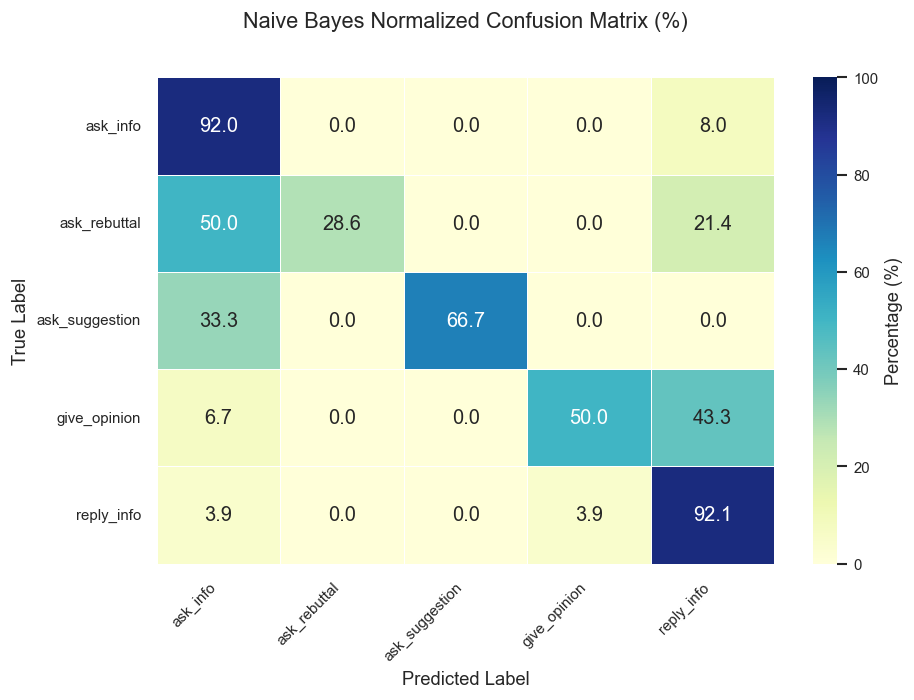

In [31]:
cm_norm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,
    normalize="true"
) * 100

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=labels,
    columns=labels
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm_norm_df,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100,
    ax=ax
)

style_report_plot(
    ax,
    title="Naive Bayes Normalized Confusion Matrix (%)",
    xlabel="Predicted Label",
    ylabel="True Label",
    xtick_rotation=45,
    ytick_rotation=0
)

plt.show()

#### Per-label F1-score

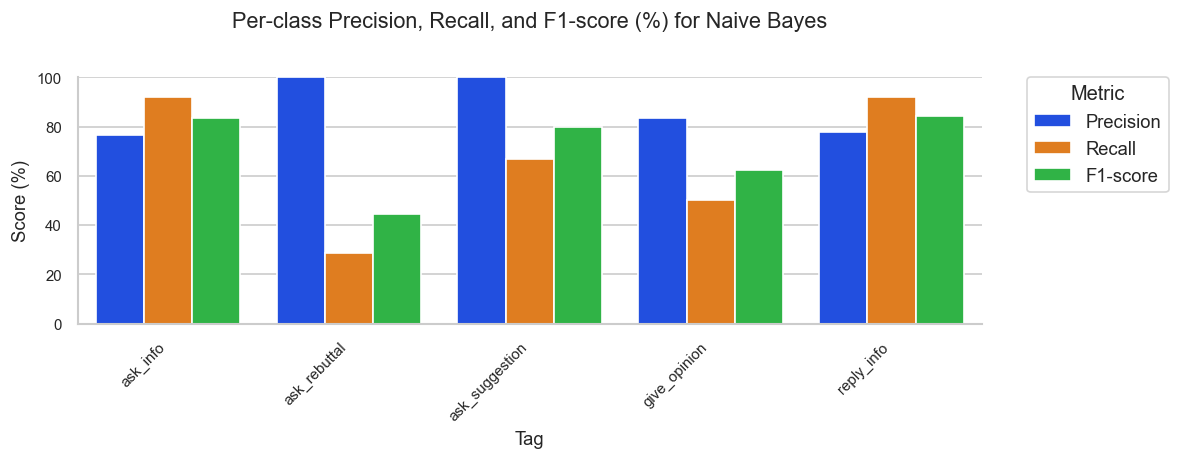

,tag,Precision,Recall,F1-score,Support
0,ask_info,0.766667,0.920000,0.836364,50
1,ask_rebuttal,1.000000,0.285714,0.444444,14
2,ask_suggestion,1.000000,0.666667,0.800000,6
3,give_opinion,0.833333,0.500000,0.625000,30
4,reply_info,0.777778,0.921053,0.843373,76


In [32]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=labels,
    zero_division=0
)

nb_class_metrics = pd.DataFrame({
    "tag":       labels,
    "Precision": precision,
    "Recall":    recall,
    "F1-score":  f1,
    "Support":   support
})

nb_class_metrics_long = nb_class_metrics.melt(
    id_vars=["tag", "Support"],
    value_vars=["Precision", "Recall", "F1-score"],
    var_name="Metric",
    value_name="Score"
)

nb_class_metrics_long["Score"] = nb_class_metrics_long["Score"] * 100

custom_palette = "bright"

plt.figure(figsize=REPORT_FIGSIZE)

ax = sns.barplot(
    data=nb_class_metrics_long,
    x="tag",
    y="Score",
    hue="Metric",
    palette=custom_palette
)

ax.set_ylim(0, 100)

ax.legend(
    title="Metric",
    frameon=True,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)

style_report_plot(
    ax,
    title="Per-class Precision, Recall, and F1-score (%) for Naive Bayes",
    xlabel="Tag",
    ylabel="Score (%)"
)

plt.tight_layout()
plt.show()

nb_class_metrics

#### Previous to current label transition

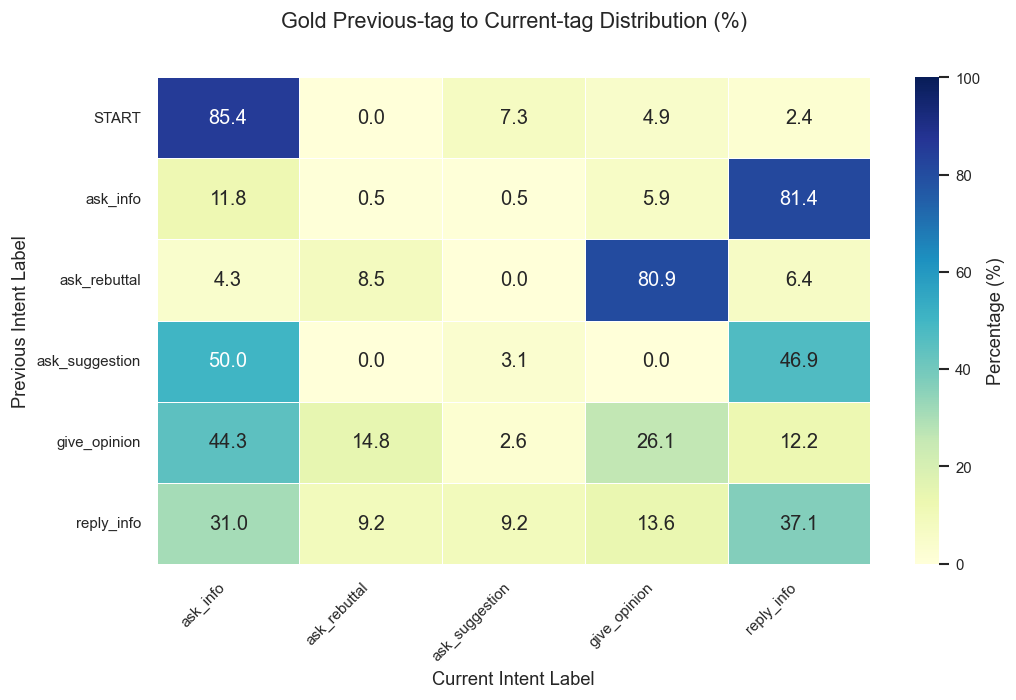

In [33]:
# Build previous gold tag from ordered dialogues
df_plot = df_temp.copy()
df_plot = df_plot.sort_values(sort_cols).reset_index(drop=True)

df_plot["prev_tag"] = (
    df_plot.groupby("dialogue_number")["tag"]
    .shift(1)
    .fillna("START")
)

transition_table = (
    pd.crosstab(df_plot["prev_tag"], df_plot["tag"], normalize="index") * 100
)

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    transition_table,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100,
    ax=ax
)

style_report_plot(
    ax,
    title="Gold Previous-tag to Current-tag Distribution (%)",
    xlabel="Current Intent Label",
    ylabel="Previous Intent Label",
    xtick_rotation=45,
    ytick_rotation=0
)

plt.show()

- Note: The gold transition heatmap above shows the true sequential structure in the data. Because Naive Bayes ignores this structure entirely, comparing its predictions against HMM, MEMM, and CRF directly measures how much value those models extract from modelling intent transitions.

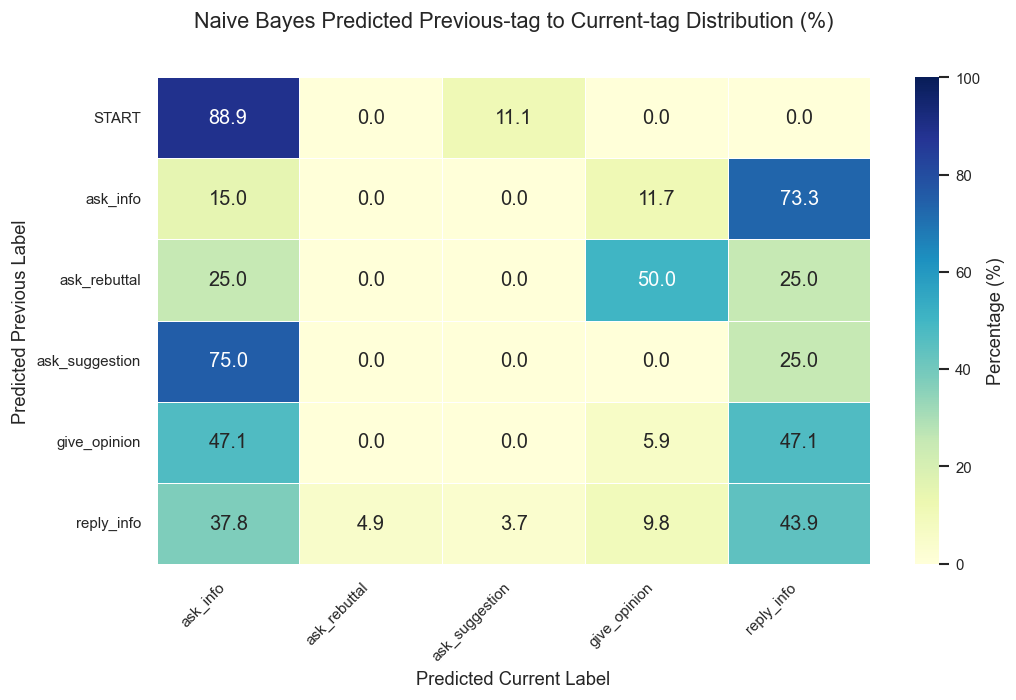

In [34]:
nb_plot_df = results_df.copy()
nb_plot_df = nb_plot_df.sort_values(sort_cols).reset_index(drop=True)

nb_plot_df["prev_pred_tag"] = (
    nb_plot_df.groupby("dialogue_number")["pred_tag"]
    .shift(1)
    .fillna("START")
)

pred_transition_table = (
    pd.crosstab(nb_plot_df["prev_pred_tag"], nb_plot_df["pred_tag"], normalize="index") * 100
)

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    pred_transition_table,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100,
    ax=ax
)

style_report_plot(
    ax,
    title="Naive Bayes Predicted Previous-tag to Current-tag Distribution (%)",
    xlabel="Predicted Current Label",
    ylabel="Predicted Previous Label",
    xtick_rotation=45,
    ytick_rotation=0
)

plt.show()

- Note: If Naive Bayes predictions show a transition distribution similar to the gold distribution above, it suggests that surface-level text features already capture most of the sequential pattern implicitly. If the predicted transitions are much flatter or noisier, it confirms that explicit sequence modelling (HMM, MEMM, CRF) is adding real value.

#### Speaker/turn structure influence

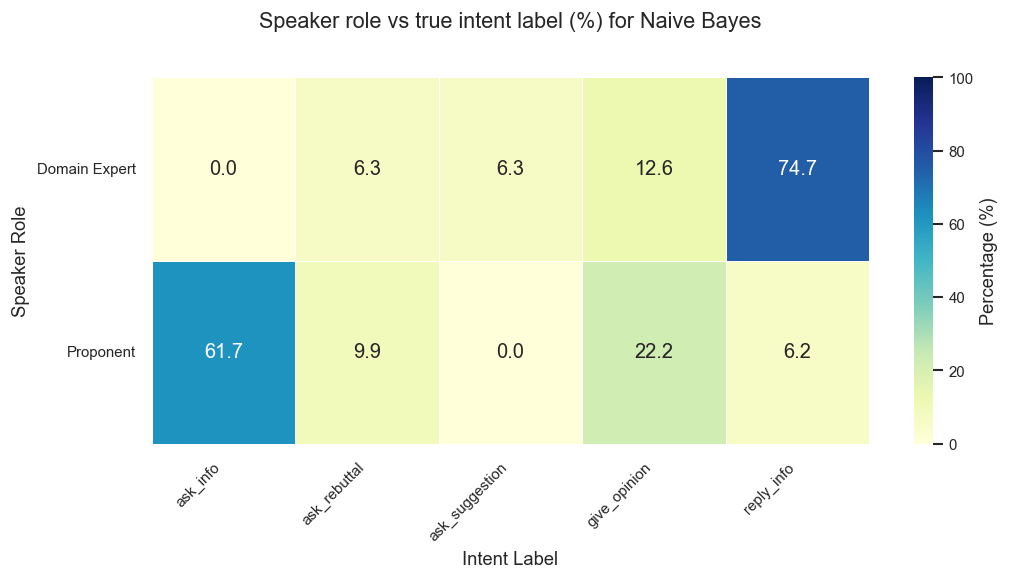

In [35]:
role_tag_table = pd.crosstab(
    results_df["role"],
    results_df["true_tag"],
    normalize="index"
) * 100

fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    role_tag_table,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100,
    ax=ax
)

style_report_plot(
    ax,
    title="Speaker role vs true intent label (%) for Naive Bayes",
    xlabel="Intent Label",
    ylabel="Speaker Role",
    xtick_rotation=45,
    ytick_rotation=0
)

plt.show()

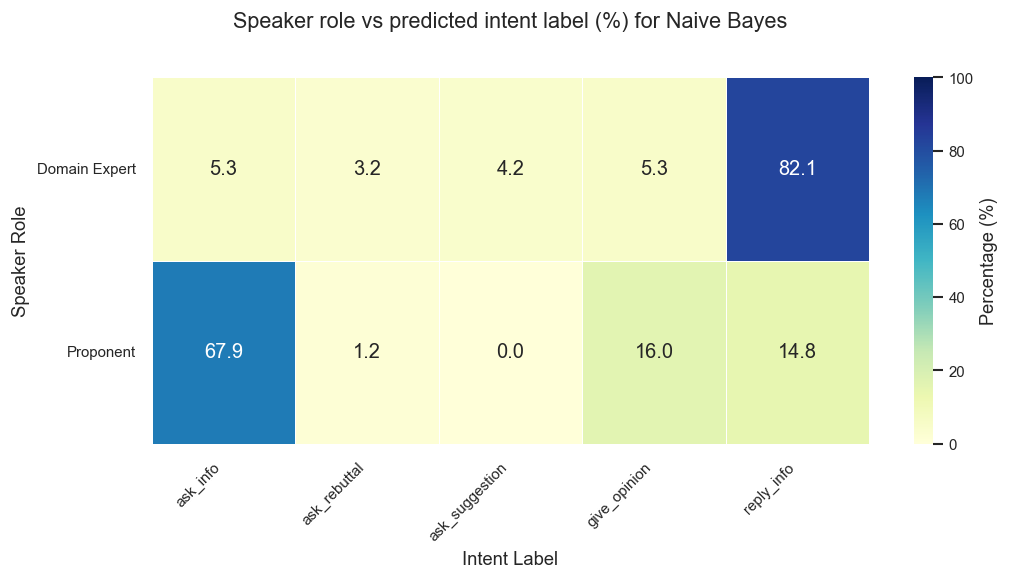

In [38]:
role_tag_table = pd.crosstab(
    results_df["role"],
    results_df["pred_tag"],
    normalize="index"
) * 100

fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    role_tag_table,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100,
    ax=ax
)

style_report_plot(
    ax,
    title="Speaker role vs predicted intent label (%) for Naive Bayes",
    xlabel="Intent Label",
    ylabel="Speaker Role",
    xtick_rotation=45,
    ytick_rotation=0
)

plt.show()

In [36]:
error_by_role = (
    results_df
    .groupby("role")["correct"]
    .agg(total="count", correct="sum")
    .assign(error_rate=lambda x: (1 - x["correct"] / x["total"]) * 100)
    .reset_index()
    .sort_values("error_rate", ascending=False)
)

print("Error rate by speaker role for Naive Bayes:")
error_by_role

Error rate by speaker role for Naive Bayes:


,role,total,correct,error_rate
1,Proponent,81,62,23.456790
0,Domain Expert,95,77,18.947368


- Note: The speaker role distribution over intent labels shows whether certain roles are systematically associated with certain intents. The error rate table shows whether the model struggles more with one speaker role than the other, which would indicate that speaker/turn structure is a meaningful signal the model is not fully capturing.